In [1]:
## Env: allcools
import xarray as xr
import pandas as pd
import numpy as np
# import umap
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
# import scanpy as sc
import seaborn as sns
import anndata as ad
from sklearn.preprocessing import normalize
from joblib import Parallel, delayed
from pathlib import Path
from collections import Counter
import glob
import math
import cooler
import re
import os
import matplotlib.gridspec as gridspec
from scipy import sparse
import h5py
import anndata
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42 
matplotlib.rcParams['font.family'] = 'Arial'
import schicluster
PACKAGE_DIR = schicluster.__path__[0]

In [2]:
cellID_merged = pd.read_csv('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/meta_file/metadata_passQC_05212026.tsv.gz',sep = '\t',index_col=0)

/tmp/ipykernel_335429/286891771.py:1: DtypeWarning: Columns (11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  cellID_merged = pd.read_csv('/datasets/Public_Datasets/Luo_BICAN_U01_human_brain_dev/snm3C_3C/meta_file/metadata_passQC_05212026.tsv.gz',sep = '\t',index_col=0)


In [ ]:
imputed_path = glob.glob('/cndd2/hex002/Luo_Development/hic_impute/*25k*.tsv')
imputed_path = [x for x in imputed_path if 'chunk' not in x]
df_list = []
for file_path in imputed_path:
    try:
        df = pd.read_csv(file_path, sep="\t", header=None)
        
        df['source_file'] = file_path
        df_list.append(df)
    except Exception as e:
        print(f"Error reading {file_path}: {e}")

In [4]:
if df_list:
    all_25k_data = pd.concat(df_list, axis=0, ignore_index=True)
    
    # Set column names based on your existing pattern
    if all_25k_data.shape[1] >= 2:
        all_25k_data.columns = ["ID", "25kb_imputed_Path"] + list(all_25k_data.columns[2:])
    
    print(f"Found {len(imputed_path)} files")
    print(f"Columns: {list(all_25k_data.columns)}")
    
    # Extract batch_ID from path
    all_25k_data["batch_ID"] = all_25k_data["25kb_imputed_Path"].apply(
        lambda x: Path(x).parts[Path(x).parts.index("hic_impute") + 1] if "hic_impute" in Path(x).parts else "unknown"
    )
    
    all_25k_data.head()
else:
    print("No *cell_table_25k.tsv files found")

Found 31 files
Columns: ['ID', '25kb_imputed_Path', 'source_file']


In [5]:
all_25k_data = all_25k_data.drop_duplicates(
    subset='ID',
    keep='first'
)

In [6]:
cellID_merged = cellID_merged.merge(all_25k_data[['ID','25kb_imputed_Path']], left_index=True, right_on='ID',how = 'left') 

In [7]:
cellID_merged['cluster_L3'] = (
    cellID_merged['age_groups'].astype(str) + '_' +
    cellID_merged['L1'].astype(str)+ '-' + cellID_merged['L2'].astype(str)+ '-' + cellID_merged['L3'].astype(str)
)
cellID_merged['age_L2'] = (
    cellID_merged['age_groups'].astype(str) + '_' +
    cellID_merged['L1'].astype(str)+ '-' + cellID_merged['L2'].astype(str)
)

In [8]:
cellID_merged.index = cellID_merged['ID']

## Read Domain

In [11]:
sc_border = anndata.read_h5ad('/cndd2/hex002/Luo_Development/hic_domain/ALL_cell_boundary_110425.h5ad')

In [12]:
sc_border.obs['age_L2'] = cellID_merged.loc[sc_border.obs.index, 'age_L2']
sc_border.obs['age_L2'] = cellID_merged.loc[sc_border.obs.index, 'age_L2']
sc_border.obs['age_L3'] = cellID_merged.loc[sc_border.obs.index, 'cluster_L3']
sc_border.obs['fine2_age_groups'] = cellID_merged.loc[sc_border.obs.index, 'age_groups']
sc_border.obs['L2'] = cellID_merged.loc[sc_border.obs.index, 'L2']
sc_border.obs['L3'] = cellID_merged.loc[sc_border.obs.index, 'L3']

## Number of Domain across cells per L3_cluster

In [18]:
row_sums = np.array(sc_border.X.sum(axis=1)).ravel().astype(int)
sc_border.obs["n_boundaries"] = row_sums
sc_border.obs["n_domains"] = row_sums // 2

In [19]:
age_colors = {
    '2T': '#30123b',
    '3T': '#2a92e5',
    '1m': '#27e37b',
    '4-7m': '#f6d531',
    'adult': '#aa40fc'
}

In [25]:
def make_row_boxplot_domains(
    ax,
    df,
    l2_list,
    box_width=0.8
):
    """
    Plot boxplots of number of domains only (no count panel),
    grouped by L2/L3 with gaps and L2 brackets.
    """

    dsub = df[df['L2'].isin(l2_list)].copy()
    dsub['xcat'] = dsub['L2'].astype(str) + '||' + dsub['L3'].astype(str)

    # -------------------------------------------------
    # Build x-order with gaps + L2 blocks
    # -------------------------------------------------
    xorder = []
    l2_blocks = []
    pos = 0

    for l2 in l2_list:
        l3s = (
            dsub.loc[dsub['L2'] == l2, 'L3']
            .astype(str)
            .unique()
            .tolist()
        )
        l3s = sorted(l3s)
        if not l3s:
            continue

        block = [f"{l2}||{l3}" for l3 in l3s]
        xorder.extend(block)
        l2_blocks.append((pos, pos + len(block) - 1, l2))
        pos += len(block)

        # add a visual gap
        xorder.append(f"GAP__{l2}")
        pos += 1

    if xorder and xorder[-1].startswith("GAP__"):
        xorder = xorder[:-1]

    # -------------------------------------------------
    # Boxplot
    # -------------------------------------------------
    sns.boxplot(
        data=dsub,
        x='xcat',
        y='n_domains',
        hue='fine2_age_groups',
        hue_order=age_order,
        palette=age_colors,
        order=xorder,
        showfliers=False,
        width=box_width,
        ax=ax
    )

    # -------------------------------------------------
    # X ticks (L3 labels only, no GAP)
    # -------------------------------------------------
    tick_labels, tick_pos = [], []
    for i, lab in enumerate(xorder):
        if lab.startswith("GAP__"):
            continue
        tick_labels.append(lab.split("||", 1)[1])
        tick_pos.append(i)

    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=12)

    # -------------------------------------------------
    # L2 brackets + labels
    # -------------------------------------------------
    ymax = ax.get_ylim()[1]
    y = ymax * 1.05

    for start, end, l2 in l2_blocks:
        ax.plot(
            [start - 0.4, end + 0.4],
            [y, y],
            lw=1.2,
            color='black',
            clip_on=False
        )
        ax.text(
            (start + end) / 2,
            y * 1.01,
            l2,
            ha='center',
            va='bottom',
            fontsize=13,
            fontweight='bold'
        )

    ax.set_ylim(ax.get_ylim()[0], y * 1.12)

    # -------------------------------------------------
    # Cosmetics
    # -------------------------------------------------
    ax.set_ylabel("Number of domains", fontsize=14)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_xlabel("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

    if ax.get_legend() is not None:
        ax.get_legend().remove()

/tmp/ipykernel_335429/4041907637.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.94])


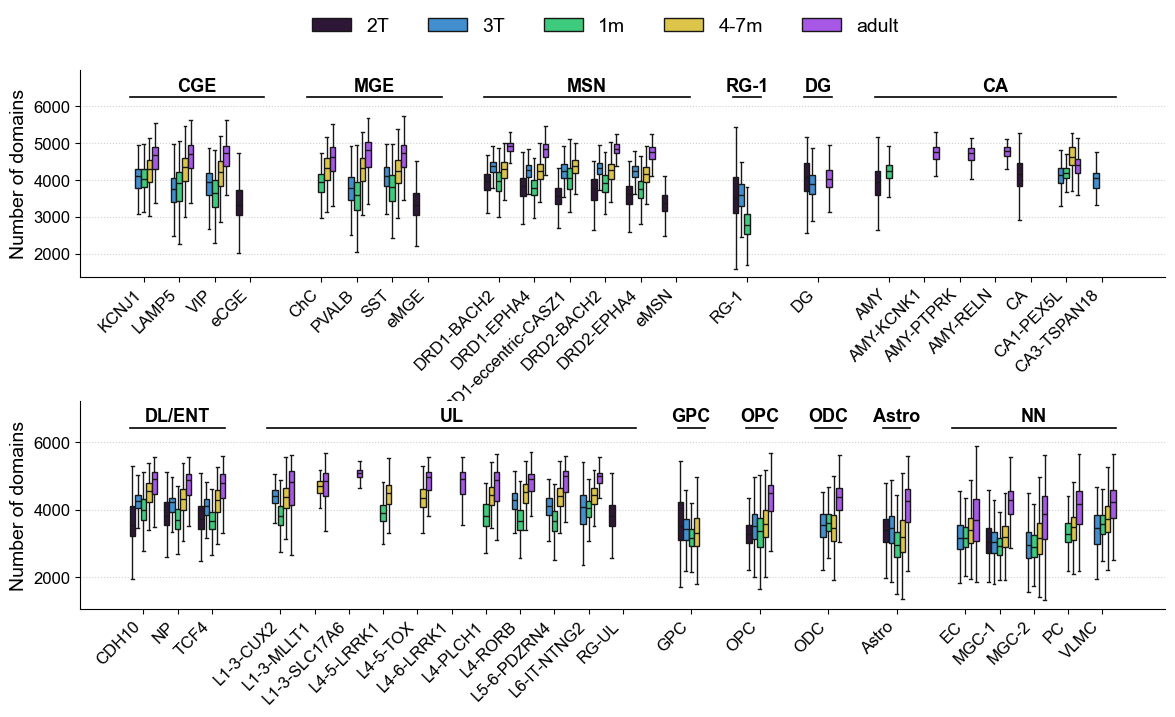

In [26]:
fig = plt.figure(figsize=(14, 7))

outer = gridspec.GridSpec(2, 1, hspace=0.6)

# Row 1
ax0 = fig.add_subplot(outer[0])
make_row_boxplot_domains(ax0, plot_df, rows_l2[0])

# Row 2
ax1 = fig.add_subplot(outer[1])
make_row_boxplot_domains(ax1, plot_df, rows_l2[1])

# Global legend
handles, labels = ax0.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(age_order),
    frameon=False,
    fontsize=14,
    bbox_to_anchor=(0.5, 0.98)
)

fig.tight_layout(rect=[0, 0, 1, 0.94])
# plt.savefig('/cndd2/hex002/Luo_Development/domain_analysis/domain_number_boxplot.pdf',dpi = 300)
plt.show()